<a href="https://colab.research.google.com/github/EduardoShoiti/tech-challenge-3/blob/main/Notebooks/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Usar se estiver no Google Colab

In [ ]:
REPO_URL = "https://github.com/EduardoShoiti/tech-challenge-3.git"
REPO_NAME = "tech-challenge-fase3"

!rm -rf /content/{REPO_NAME}
!git clone {REPO_URL} /content/{REPO_NAME}

Cloning into '/content/tech-challenge-fase3'...
remote: Enumerating objects: 13, done.
remote: Total 13 (delta 0), reused 0 (delta 0), pack-reused 13 (from 1)
Receiving objects: 100% (13/13), 158.46 MiB | 30.27 MiB/s, done.


In [ ]:
DATA_PATH = f"/content/{REPO_NAME}/data/"

## Usar se estiver rodando no repositório

In [ ]:
DATA_PATH = f"data/"

## Libs

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [ ]:
df = pd.read_parquet(DATA_PATH)
df.shape
df.head()

,id_municipio,id_escola,id_aluno,codigo_uf,sigla_uf,regiao,serie,rede,caderno,presenca,...,brasil_taxa_alfabetizacao_pct,meta_brasil_2024_pct,meta_brasil_2025_pct,meta_brasil_2026_pct,meta_brasil_2027_pct,meta_brasil_2028_pct,meta_brasil_2029_pct,meta_brasil_2030_pct,meta_brasil_percentual_participacao_pct,ano
0,1500800,60001741,15013099,15,PA,Norte,2,3,1,0,...,55.9,59.9,63.77,67.47,70.97,74.23,77.24,80,86.0,2023
1,2928000,60018151,29015365,29,BA,Nordeste,2,3,1,0,...,55.9,59.9,63.77,67.47,70.97,74.23,77.24,80,86.0,2023
2,3306008,60023797,33150031,33,RJ,Sudeste,2,3,1,0,...,55.9,59.9,63.77,67.47,70.97,74.23,77.24,80,86.0,2023
3,3301009,60025615,33020402,33,RJ,Sudeste,2,3,1,0,...,55.9,59.9,63.77,67.47,70.97,74.23,77.24,80,86.0,2023
4,4205456,60036355,42030273,42,SC,Sul,2,3,1,0,...,55.9,59.9,63.77,67.47,70.97,74.23,77.24,80,86.0,2023


In [ ]:
df.head()

,id_municipio,id_escola,id_aluno,codigo_uf,sigla_uf,regiao,serie,rede,caderno,presenca,...,brasil_taxa_alfabetizacao_pct,meta_brasil_2024_pct,meta_brasil_2025_pct,meta_brasil_2026_pct,meta_brasil_2027_pct,meta_brasil_2028_pct,meta_brasil_2029_pct,meta_brasil_2030_pct,meta_brasil_percentual_participacao_pct,ano
0,1500800,60001741,15013099,15,PA,Norte,2,3,1,0,...,55.9,59.9,63.77,67.47,70.97,74.23,77.24,80,86.0,2023
1,2928000,60018151,29015365,29,BA,Nordeste,2,3,1,0,...,55.9,59.9,63.77,67.47,70.97,74.23,77.24,80,86.0,2023
2,3306008,60023797,33150031,33,RJ,Sudeste,2,3,1,0,...,55.9,59.9,63.77,67.47,70.97,74.23,77.24,80,86.0,2023
3,3301009,60025615,33020402,33,RJ,Sudeste,2,3,1,0,...,55.9,59.9,63.77,67.47,70.97,74.23,77.24,80,86.0,2023
4,4205456,60036355,42030273,42,SC,Sul,2,3,1,0,...,55.9,59.9,63.77,67.47,70.97,74.23,77.24,80,86.0,2023


In [ ]:
df.columns

Index(['id_municipio', 'id_escola', 'id_aluno', 'codigo_uf', 'sigla_uf',
       'regiao', 'serie', 'rede', 'caderno', 'presenca',
       'preenchimento_caderno', 'proficiencia', 'peso_aluno', 'alfabetizado',
       'municipio_taxa_alfabetizacao_pct', 'municipio_media_portugues',
       'meta_municipio_taxa_alfabetizacao_pct', 'meta_municipio_2024_pct',
       'meta_municipio_2025_pct', 'meta_municipio_2026_pct',
       'meta_municipio_2027_pct', 'meta_municipio_2028_pct',
       'meta_municipio_2029_pct', 'meta_municipio_2030_pct',
       'meta_municipio_nivel_alfabetizacao',
       'meta_municipio_percentual_participacao_pct',
       'uf_taxa_alfabetizacao_pct', 'uf_media_portugues',
       'meta_uf_taxa_alfabetizacao_pct', 'meta_uf_2024_pct',
       'meta_uf_2025_pct', 'meta_uf_2026_pct', 'meta_uf_2027_pct',
       'meta_uf_2028_pct', 'meta_uf_2029_pct', 'meta_uf_2030_pct',
       'meta_uf_percentual_participacao_pct', 'brasil_taxa_alfabetizacao_pct',
       'meta_brasil_2024_pct', '

In [ ]:
df['sigla_uf'].value_counts()

,count
sigla_uf,
SP,443777
MG,413557
RJ,311198
PR,277446
BA,253300
RS,229410
PA,204949
SC,201171
CE,190190


In [ ]:
value_rede = {
    1: "Federal",
    2: "Estadual",
    3: "Municipal",
    4: "Privada",
    5: "Pública (Estadual e Municipal)",
    6: "Pública (Federal, Estadual e Municipal)"
}

df['rede_desc'] = df['rede'].map(value_rede)
df[['rede', 'rede_desc']].head()

,rede,rede_desc
0,3,Municipal
1,3,Municipal
2,3,Municipal
3,3,Municipal
4,3,Municipal


## Criar uma amostra do dataset

In [ ]:
df["stratify_key"] = (
    df["alfabetizado"].astype("string") + "_" +
    df["ano"].astype("string") + "_" +
    df["sigla_uf"].astype("string") + "_" +
    df["rede_desc"].astype("string")
)

df.head()

,id_municipio,id_escola,id_aluno,codigo_uf,sigla_uf,regiao,serie,rede,caderno,presenca,...,meta_brasil_2025_pct,meta_brasil_2026_pct,meta_brasil_2027_pct,meta_brasil_2028_pct,meta_brasil_2029_pct,meta_brasil_2030_pct,meta_brasil_percentual_participacao_pct,ano,rede_desc,stratify_key
0,1500800,60001741,15013099,15,PA,Norte,2,3,1,0,...,63.77,67.47,70.97,74.23,77.24,80,86.0,2023,Municipal,0_2023_PA_Municipal
1,2928000,60018151,29015365,29,BA,Nordeste,2,3,1,0,...,63.77,67.47,70.97,74.23,77.24,80,86.0,2023,Municipal,0_2023_BA_Municipal
2,3306008,60023797,33150031,33,RJ,Sudeste,2,3,1,0,...,63.77,67.47,70.97,74.23,77.24,80,86.0,2023,Municipal,0_2023_RJ_Municipal
3,3301009,60025615,33020402,33,RJ,Sudeste,2,3,1,0,...,63.77,67.47,70.97,74.23,77.24,80,86.0,2023,Municipal,0_2023_RJ_Municipal
4,4205456,60036355,42030273,42,SC,Sul,2,3,1,0,...,63.77,67.47,70.97,74.23,77.24,80,86.0,2023,Municipal,0_2023_SC_Municipal


In [ ]:
# Remove estratos muito pequenos
strata_counts = df["stratify_key"].value_counts()
valid_strata = strata_counts[strata_counts >= 10].index

df_valid = df[df["stratify_key"].isin(valid_strata)].copy()
df_small_strata = df[~df["stratify_key"].isin(valid_strata)].copy()

In [ ]:
sample_percentage = 0.1  # 10% da amostra

df_sample, _ = train_test_split(
    df_valid,
    train_size=sample_percentage,
    stratify=df_valid["stratify_key"],
    random_state=42
)

# inclui estratos raros para não perder casos pequenos
df_sample = pd.concat([df_sample, df_small_strata], ignore_index=True)
df_sample = df_sample.drop(columns=["stratify_key"])

df_sample.shape
df_sample

,id_municipio,id_escola,id_aluno,codigo_uf,sigla_uf,regiao,serie,rede,caderno,presenca,...,meta_brasil_2024_pct,meta_brasil_2025_pct,meta_brasil_2026_pct,meta_brasil_2027_pct,meta_brasil_2028_pct,meta_brasil_2029_pct,meta_brasil_2030_pct,meta_brasil_percentual_participacao_pct,ano,rede_desc
0,4120903,60033120,41000620,41,PR,Sul,2,3,10,1,...,59.9,63.77,67.47,70.97,74.23,77.24,80,87.37,2024,Municipal
1,1101401,60000230,11001863,11,RO,Norte,2,3,12,1,...,59.9,63.77,67.47,70.97,74.23,77.24,80,86.00,2023,Municipal
2,2927408,60017747,29117397,29,BA,Nordeste,2,3,8,1,...,59.9,63.77,67.47,70.97,74.23,77.24,80,86.00,2023,Municipal
3,1300904,60001148,13005111,13,AM,Norte,2,3,1,1,...,59.9,63.77,67.47,70.97,74.23,77.24,80,87.37,2024,Municipal
4,3303500,60024793,33066826,33,RJ,Sudeste,2,3,13,1,...,59.9,63.77,67.47,70.97,74.23,77.24,80,86.00,2023,Municipal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
386811,1709500,60004247,17006121,17,TO,Norte,2,4,4,1,...,59.9,63.77,67.47,70.97,74.23,77.24,80,87.37,2024,Privada
386812,5221601,60040930,52075072,52,GO,Centro-Oeste,2,2,4,1,...,59.9,63.77,67.47,70.97,74.23,77.24,80,87.37,2024,Estadual
386813,1709500,60004247,17006136,17,TO,Norte,2,4,5,1,...,59.9,63.77,67.47,70.97,74.23,77.24,80,87.37,2024,Privada
386814,1709500,60004247,17006114,17,TO,Norte,2,4,4,1,...,59.9,63.77,67.47,70.97,74.23,77.24,80,87.37,2024,Privada



Distribuição: alfabetizado


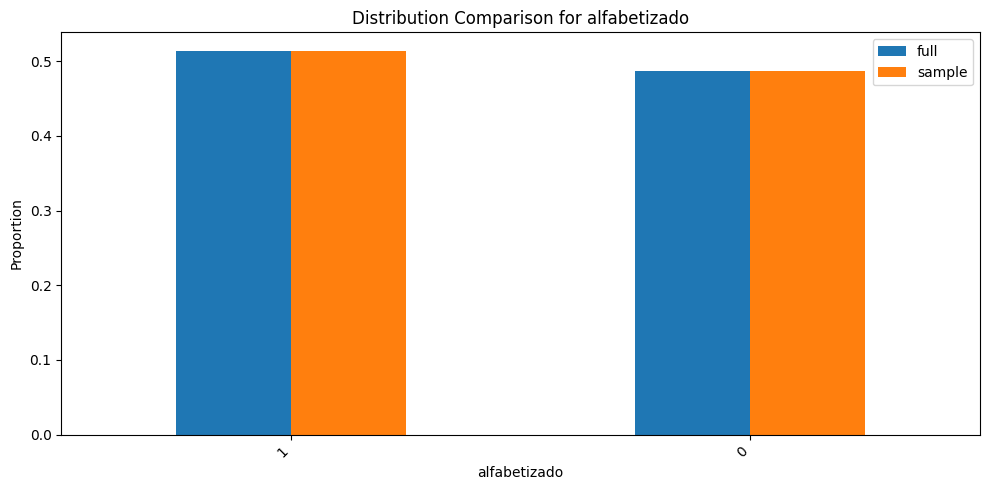

,full,sample,diff_pp
alfabetizado,,,
0,0.486932,0.48695,0.001774
1,0.513068,0.51305,-0.001774



Distribuição: ano


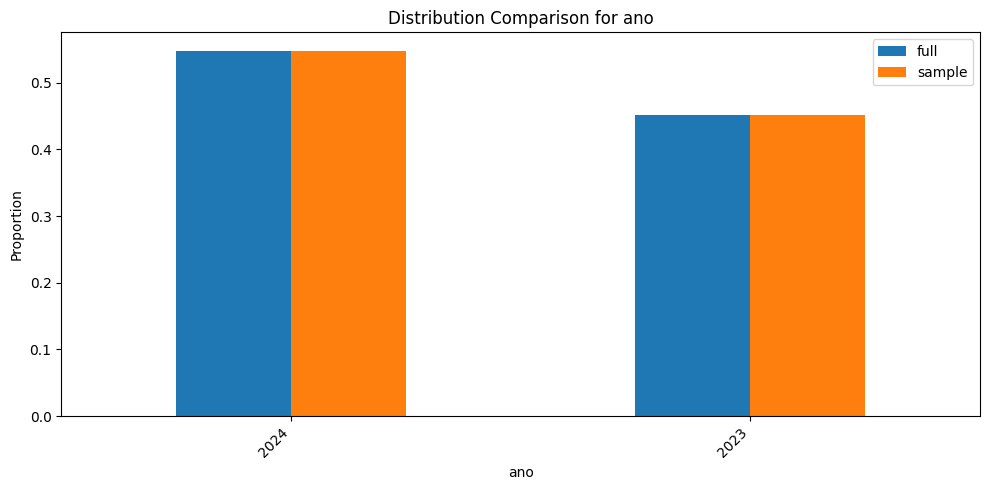

,full,sample,diff_pp
ano,,,
2023,0.451768,0.451747,-0.002113
2024,0.548232,0.548253,0.002113



Distribuição: sigla_uf


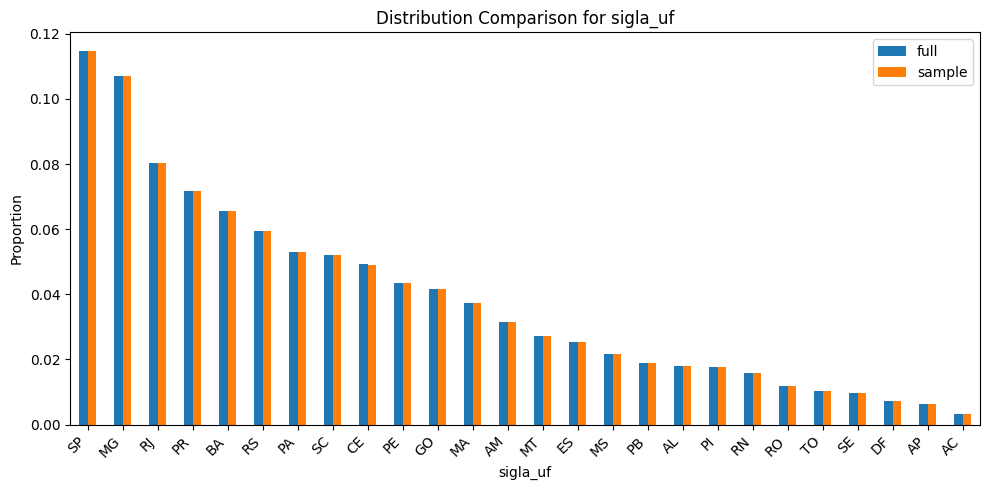

,full,sample,diff_pp
sigla_uf,,,
AC,0.003272,0.003270,-1.428779e-04
AL,0.017883,0.017882,-1.002840e-04
AM,0.031454,0.031452,-2.084725e-04
AP,0.006445,0.006445,-9.729289e-07
BA,0.065486,0.065481,-5.310860e-04
CE,0.049170,0.049163,-7.216969e-04
DF,0.007161,0.007161,2.189956e-05
ES,0.025341,0.025340,-1.054751e-04
GO,0.041600,0.041622,2.231099e-03



Distribuição: rede_desc


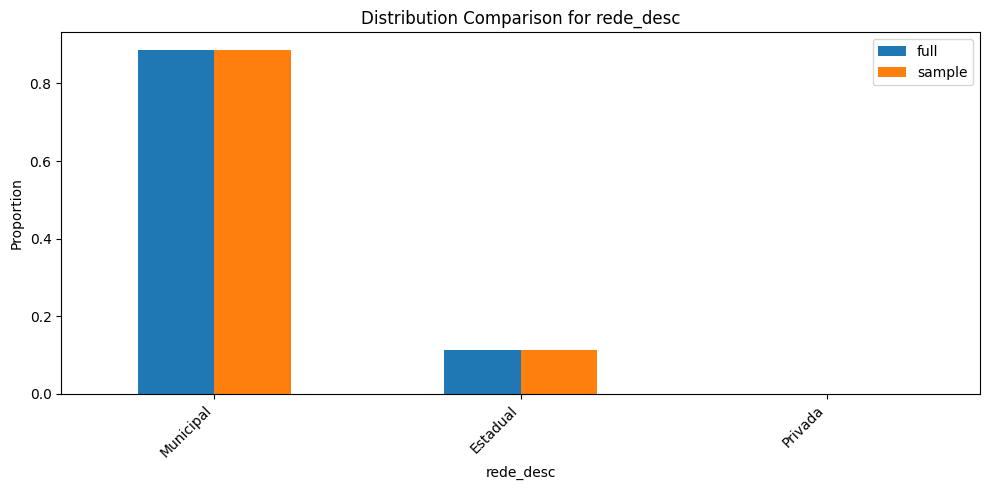

,full,sample,diff_pp
rede_desc,,,
Estadual,0.112564,0.112586,0.002168
Municipal,0.887429,0.887386,-0.004366
Privada,0.000006,0.000028,0.002197


In [ ]:
def compare_distribution(df_full, df_sample, column):
    full_dist = df_full[column].value_counts(normalize=True).rename("full")
    sample_dist = df_sample[column].value_counts(normalize=True).rename("sample")

    comparison = pd.concat([full_dist, sample_dist], axis=1).fillna(0)
    comparison["diff_pp"] = (comparison["sample"] - comparison["full"]) * 100

    # Plotting the comparison
    fig, ax = plt.subplots(figsize=(10, 5))
    comparison[['full', 'sample']].plot(kind='bar', ax=ax)
    ax.set_title(f'Distribution Comparison for {column}')
    ax.set_ylabel('Proportion')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    return comparison.sort_index()


for col in ["alfabetizado", "ano", "sigla_uf", "rede_desc"]:
    print(f"\nDistribuição: {col}")
    display(compare_distribution(df, df_sample, col))

In [ ]:
output_dir = f"/content/{REPO_NAME}/data/sample"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, "df_alunos_sample.parquet")
df_sample.to_parquet(output_path, index=False)

print(f"df_sample saved to: {output_path}")

df_sample saved to: /content/tech-challenge-fase3/data/sample/df_alunos_sample.parquet


## EDA

1. Qual é a distribuição da variável target (alfabetizado)?
2. A alfabetização varia por região, UF, rede, série e ano?
3. Presença, preenchimento do caderno e proficiência se relacionam com alfabetização?
4. Quais variáveis têm muitos nulos?
5. Existem variáveis com risco de data leakage?
6. Existem variáveis categóricas de alta cardinalidade?
7. Quais variáveis parecem boas candidatas para o modelo?

In [ ]:
df_sample_eda = pd.read_parquet("/content/tech-challenge-fase3/data/sample/df_alunos_sample.parquet")
df_sample_eda.shape
df_sample_eda.head()

,id_municipio,id_escola,id_aluno,codigo_uf,sigla_uf,regiao,serie,rede,caderno,presenca,...,meta_brasil_2024_pct,meta_brasil_2025_pct,meta_brasil_2026_pct,meta_brasil_2027_pct,meta_brasil_2028_pct,meta_brasil_2029_pct,meta_brasil_2030_pct,meta_brasil_percentual_participacao_pct,ano,rede_desc
0,4120903,60033120,41000620,41,PR,Sul,2,3,10,1,...,59.9,63.77,67.47,70.97,74.23,77.24,80,87.37,2024,Municipal
1,1101401,60000230,11001863,11,RO,Norte,2,3,12,1,...,59.9,63.77,67.47,70.97,74.23,77.24,80,86.00,2023,Municipal
2,2927408,60017747,29117397,29,BA,Nordeste,2,3,8,1,...,59.9,63.77,67.47,70.97,74.23,77.24,80,86.00,2023,Municipal
3,1300904,60001148,13005111,13,AM,Norte,2,3,1,1,...,59.9,63.77,67.47,70.97,74.23,77.24,80,87.37,2024,Municipal
4,3303500,60024793,33066826,33,RJ,Sudeste,2,3,13,1,...,59.9,63.77,67.47,70.97,74.23,77.24,80,86.00,2023,Municipal


In [ ]:
df_sample_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386816 entries, 0 to 386815
Data columns (total 48 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   id_municipio                                386816 non-null  int64  
 1   id_escola                                   386816 non-null  int64  
 2   id_aluno                                    386816 non-null  int64  
 3   codigo_uf                                   386816 non-null  int64  
 4   sigla_uf                                    386816 non-null  object 
 5   regiao                                      386816 non-null  object 
 6   serie                                       386816 non-null  int64  
 7   rede                                        386816 non-null  int64  
 8   caderno                                     386816 non-null  int64  
 9   presenca                                    386816 non-null  int64  
 

In [ ]:
duplicados = df_sample_eda.duplicated().sum()

print(f"Percentual duplicado: {duplicados / len(df_sample_eda):.4%}")

Percentual duplicado: 0.0000%


### Distribuição da variável target

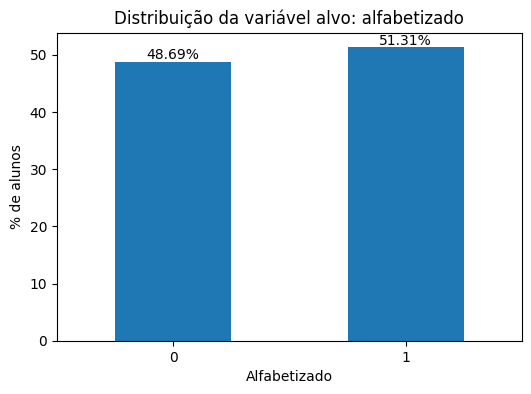

In [ ]:
# Distribuição da variável target
target_dist = df_sample_eda["alfabetizado"].value_counts(normalize=True).sort_index() * 100

ax = target_dist.plot(kind="bar", figsize=(6, 4))
ax.set_title("Distribuição da variável alvo: alfabetizado")
ax.set_xlabel("Alfabetizado")
ax.set_ylabel("% de alunos")
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

### Colunas com mais nulos

In [ ]:
# Colunas com mais nulos
missing = (
    df_sample_eda
    .isna()
    .mean()
    .sort_values(ascending=False)
    .mul(100)
    .reset_index()
)

missing.columns = ["coluna", "pct_nulo"]

missing

,coluna,pct_nulo
0,peso_aluno,13.247384
1,proficiencia,13.247384
2,meta_municipio_2024_pct,5.323720
3,meta_municipio_taxa_alfabetizacao_pct,4.471894
4,meta_municipio_nivel_alfabetizacao,4.471894
5,meta_municipio_percentual_participacao_pct,4.471894
6,meta_municipio_2028_pct,3.967519
7,meta_municipio_2027_pct,3.967519
8,meta_municipio_2026_pct,3.967519
9,meta_municipio_2025_pct,3.967519


### Cardinalidade das variáveis categóricas

In [ ]:
# Cardinalidade das variáveis categóricas
categorical_cols = df_sample_eda.select_dtypes(include=["object", "string", "category"]).columns.tolist()

cardinality = (
    df_sample_eda[categorical_cols]
    .nunique(dropna=False)
    .sort_values(ascending=False)
    .reset_index()
)

cardinality.columns = ["coluna", "qtd_valores_distintos"]
cardinality

,coluna,qtd_valores_distintos
0,sigla_uf,26
1,regiao,5
2,rede_desc,3


### Alfabetização por grupos

In [ ]:
def alfabetizacao_por_grupo(df, group_col):
    result = (
        df
        .groupby(group_col)
        .agg(
            qtd_alunos=("alfabetizado", "size"),
            taxa_alfabetizacao=("alfabetizado", "mean")
        )
        .reset_index()
    )

    result["taxa_alfabetizacao"] = result["taxa_alfabetizacao"] * 100
    result = result.sort_values("taxa_alfabetizacao", ascending=False)

    ax = result.plot(
        x=group_col,
        y="taxa_alfabetizacao",
        kind="bar",
        figsize=(10, 6),
        legend=False
    )

    for p in ax.patches:
      ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='center', xytext=(0, 5), textcoords='offset points')

    ax.set_title(f"Taxa de alfabetização por {group_col}")
    ax.set_xlabel(group_col)
    ax.set_ylabel("Taxa de alfabetização (%)")
    plt.xticks(rotation=0)
    plt.show()


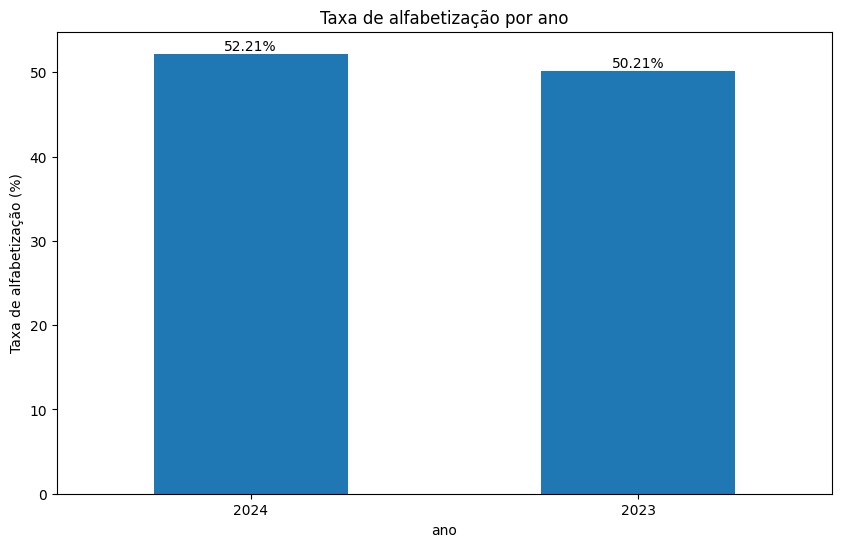

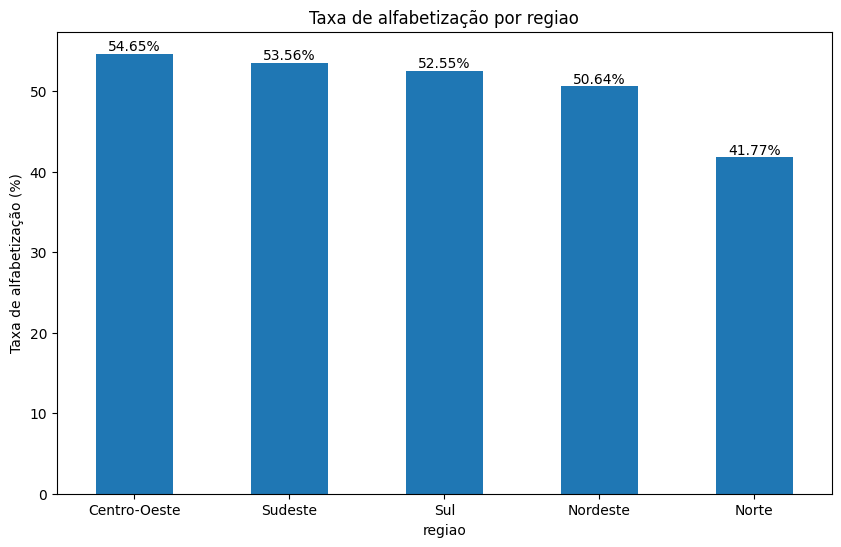

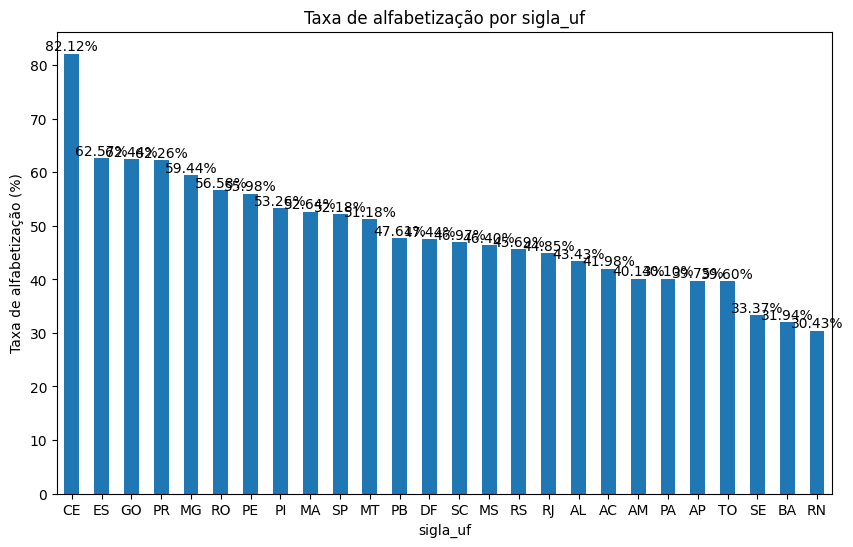

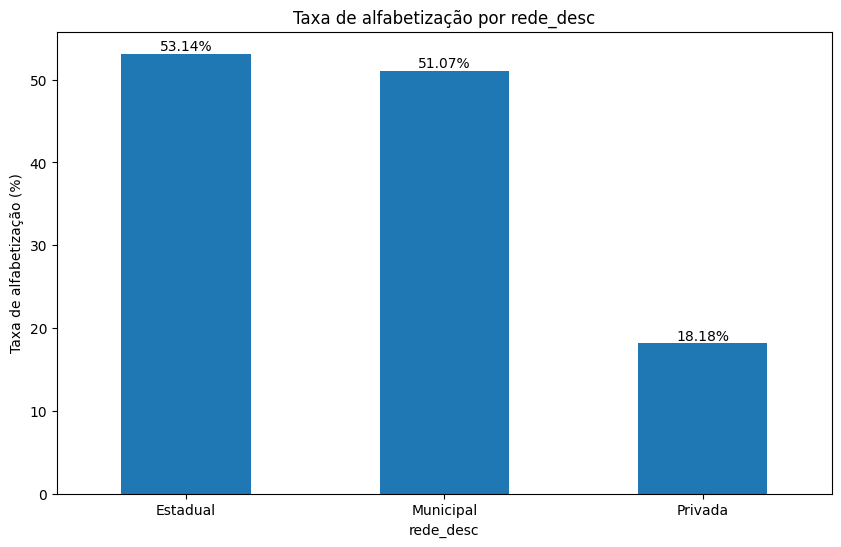

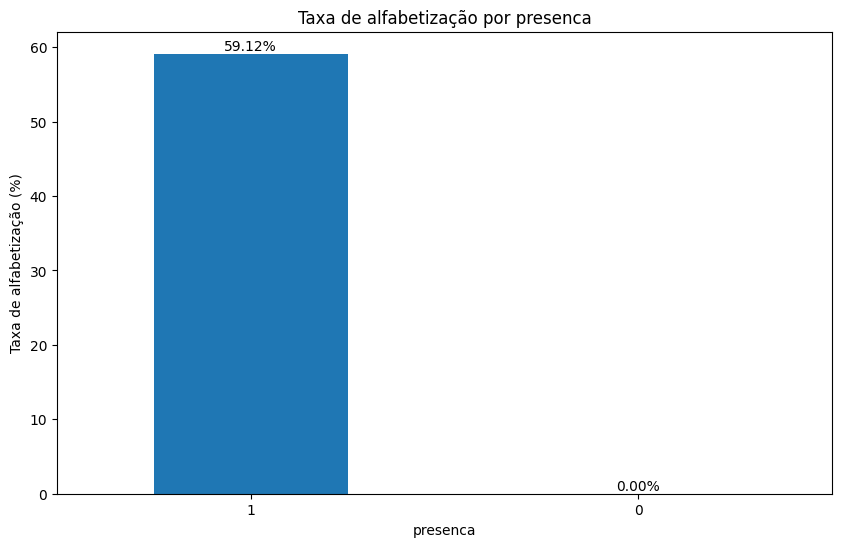

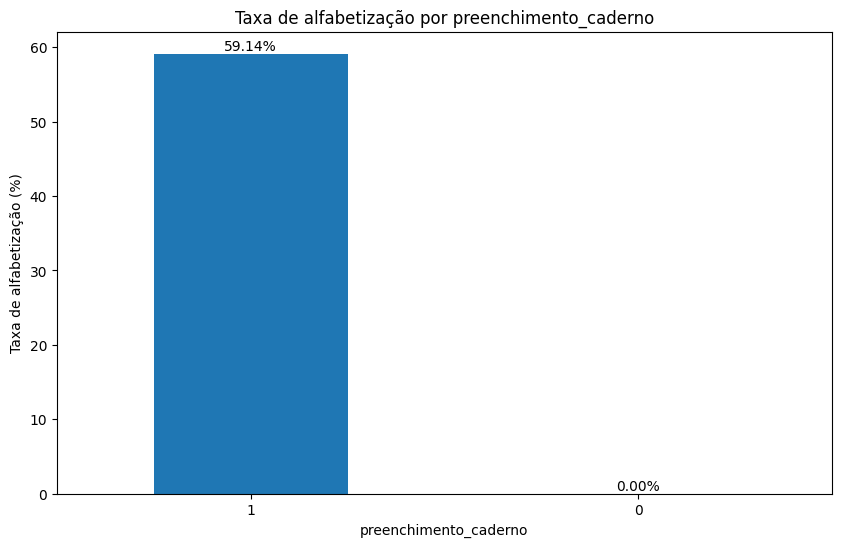

In [ ]:
cols_to_analyse = ["ano", "regiao", "sigla_uf", "rede_desc", "presenca", "preenchimento_caderno"]

for col in cols_to_analyse:
    alfabetizacao_por_grupo(df_sample_eda, col)

### Taxa de alfabetização por região e ano

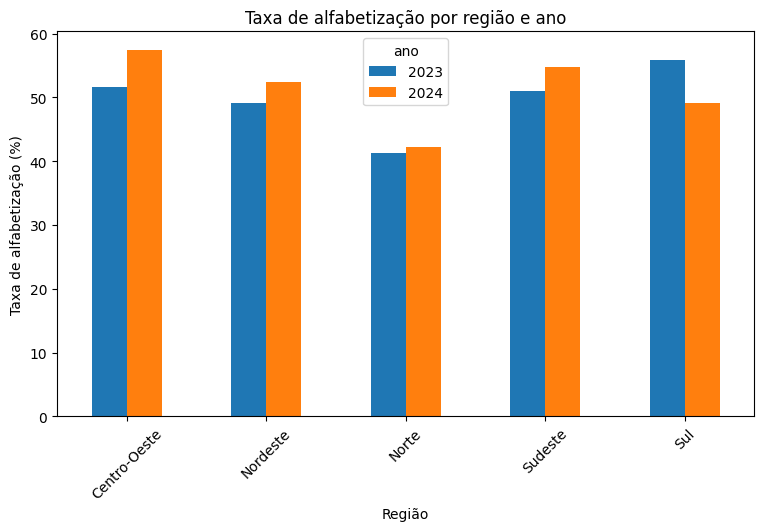

In [ ]:
pivot = (
    df_sample_eda
    .groupby(["ano", "regiao"])["alfabetizado"]
    .mean()
    .mul(100)
    .reset_index()
)

pivot_plot = pivot.pivot(index="regiao", columns="ano", values="alfabetizado")

ax = pivot_plot.plot(kind="bar", figsize=(9, 5))
ax.set_title("Taxa de alfabetização por região e ano")
ax.set_xlabel("Região")
ax.set_ylabel("Taxa de alfabetização (%)")
plt.xticks(rotation=45)
plt.show()

### Correlação das variáveis numéricas

In [ ]:
numeric_cols = df_sample_eda.select_dtypes(include=["int64", "float64", "int32"]).columns.tolist()

# Filtrar colunas numéricas que não começam com 'id'
numeric_cols = [col for col in numeric_cols if not col.startswith("id")]

In [ ]:
# Filtrando variáveis para correlação

corr_check = pd.DataFrame({
    "coluna": numeric_cols,
    "pct_nulo": df_sample_eda[numeric_cols].isna().mean().values * 100,
    "qtd_valores_distintos": df_sample_eda[numeric_cols].nunique(dropna=True).values,
})

corr_check = corr_check.sort_values(
    ["qtd_valores_distintos", "pct_nulo"],
    ascending=[True, False]
)

cols_constantes = corr_check.loc[
    corr_check["qtd_valores_distintos"] <= 1,
    "coluna"
].tolist()

cols_muito_nulas = corr_check.loc[
    corr_check["pct_nulo"] >= 80,
    "coluna"
].tolist()

cols_remover_corr = list(set(cols_constantes + cols_muito_nulas))

cols_remover_corr

['meta_brasil_2026_pct',
 'meta_brasil_2027_pct',
 'meta_brasil_2024_pct',
 'serie',
 'meta_municipio_2030_pct',
 'meta_brasil_2029_pct',
 'meta_brasil_2030_pct',
 'meta_uf_2030_pct',
 'meta_brasil_2025_pct',
 'meta_brasil_2028_pct']

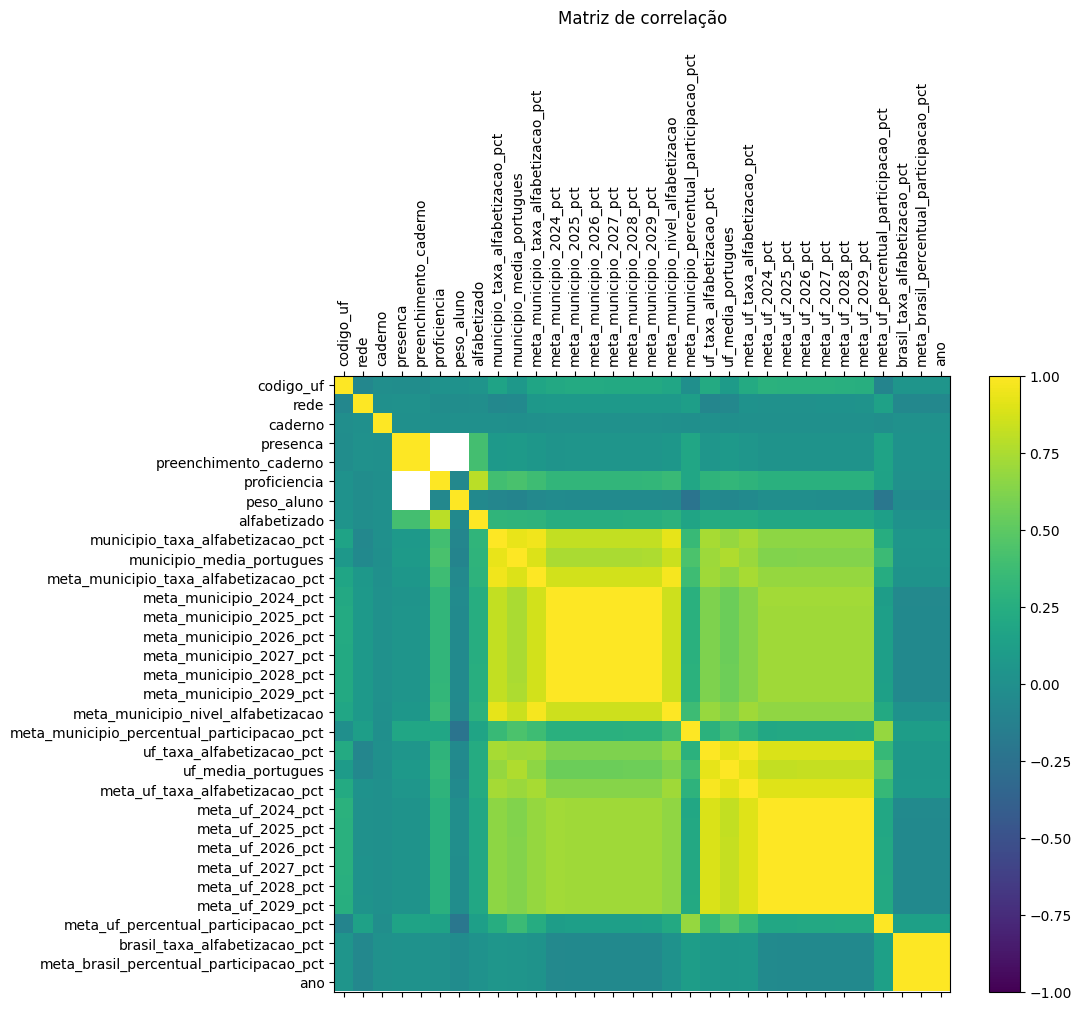

In [ ]:
corr_cols = [
    col for col in numeric_cols
    if col not in cols_remover_corr
]

corr = df_sample_eda[corr_cols].corr(numeric_only=True)

# Corrigido: `corr["alfabetizado"]` é uma Series e sort_values() é chamado diretamente.
corr["alfabetizado"].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))

cax = ax.matshow(corr, vmin=-1, vmax=1)
fig.colorbar(cax)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))

ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

ax.set_title("Matriz de correlação", pad=20)

plt.show()

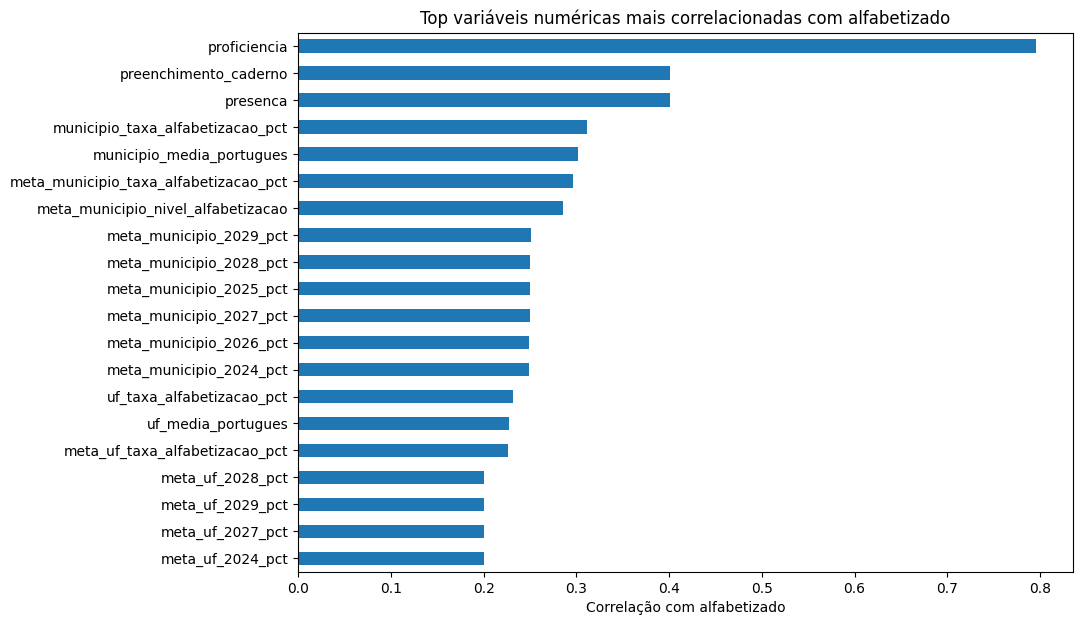

In [ ]:
target = "alfabetizado"

numeric_cols_validas = [
    col for col in numeric_cols
    if col not in cols_remover_corr
]

corr_target = (
    df_sample_eda[numeric_cols_validas]
    .corr(numeric_only=True)[target]
    .drop(labels=[target], errors="ignore")
    .dropna()
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

corr_target.head(20)

top_n = 20

corr_target_top = corr_target.head(top_n).sort_values()

ax = corr_target_top.plot(
    kind="barh",
    figsize=(10, 7)
)

ax.set_title("Top variáveis numéricas mais correlacionadas com alfabetizado")
ax.set_xlabel("Correlação com alfabetizado")
ax.set_ylabel("")
plt.show()

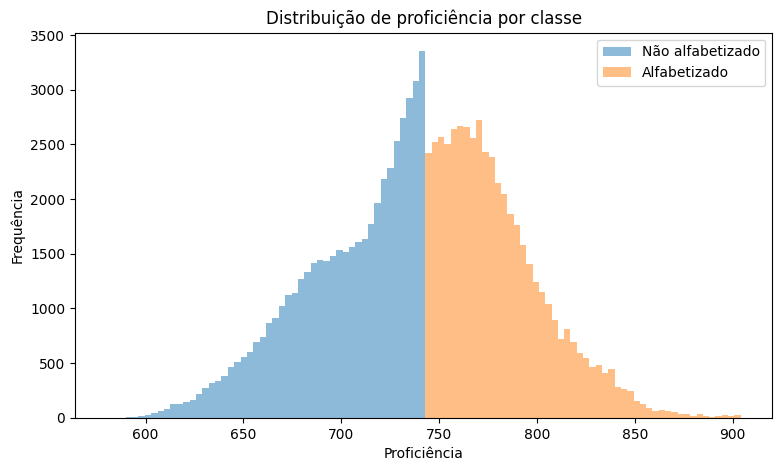

In [ ]:
col = "proficiencia"

tmp = df_sample_eda[[col, "alfabetizado"]].dropna()

ax = tmp[tmp["alfabetizado"] == 0][col].sample(min(50_000, (tmp["alfabetizado"] == 0).sum()), random_state=42).plot(
    kind="hist",
    bins=50,
    alpha=0.5,
    figsize=(9, 5),
    label="Não alfabetizado"
)

tmp[tmp["alfabetizado"] == 1][col].sample(min(50_000, (tmp["alfabetizado"] == 1).sum()), random_state=42).plot(
    kind="hist",
    bins=50,
    alpha=0.5,
    label="Alfabetizado"
)

ax.set_title("Distribuição de proficiência por classe")
ax.set_xlabel("Proficiência")
ax.set_ylabel("Frequência")
plt.legend()
plt.show()

Proficiência representa a nota que o aluno tirou no teste, por isso é altamente correlacionada a alfabetização.

Proficiência é o valor numérico e alfabetizado é o valor boleano

### Maior concentração de não alfabetizados

In [ ]:
municipio_risco = (
    df_sample_eda
    .groupby(["id_municipio", "sigla_uf", "regiao"])
    .agg(
        qtd_alunos=("alfabetizado", "size"),
        taxa_alfabetizacao=("alfabetizado", "mean"),
        media_presenca=("presenca", "mean")
    )
    .reset_index()
)

municipio_risco["taxa_alfabetizacao"] *= 100
municipio_risco["taxa_nao_alfabetizacao"] = 100 - municipio_risco["taxa_alfabetizacao"]
municipio_risco["media_presenca"] *= 100

# municipio_risco = municipio_risco[municipio_risco["qtd_alunos"] >= 30]

municipio_risco.sort_values("taxa_nao_alfabetizacao", ascending=False).head(20)

,id_municipio,sigla_uf,regiao,qtd_alunos,taxa_alfabetizacao,media_presenca,taxa_nao_alfabetizacao
5495,5219308,GO,Centro-Oeste,41,0.0,0.000000,100.0
3773,3547403,SP,Sudeste,2,0.0,100.000000,100.0
3823,3552007,SP,Sudeste,4,0.0,100.000000,100.0
364,1712157,TO,Norte,2,0.0,100.000000,100.0
1204,2413300,RN,Nordeste,10,0.0,80.000000,100.0
5451,5214804,GO,Centro-Oeste,2,0.0,100.000000,100.0
405,1718659,TO,Norte,6,0.0,83.333333,100.0
2535,3127354,MG,Sudeste,1,0.0,0.000000,100.0
3841,3553658,SP,Sudeste,4,0.0,100.000000,100.0
3829,3552551,SP,Sudeste,1,0.0,0.000000,100.0


In [ ]:
escola_risco = (
    df_sample_eda
    .groupby(["id_escola", "id_municipio", "sigla_uf", "regiao"])
    .agg(
        qtd_alunos=("alfabetizado", "size"),
        taxa_alfabetizacao=("alfabetizado", "mean"),
        media_presenca=("presenca", "mean")
    )
    .reset_index()
)

escola_risco["taxa_alfabetizacao"] *= 100
escola_risco["taxa_nao_alfabetizacao"] = 100 - escola_risco["taxa_alfabetizacao"]
escola_risco["media_presenca"] *= 100


# escola_risco = escola_risco[escola_risco["qtd_alunos"] >= 20]

escola_risco.sort_values("taxa_nao_alfabetizacao", ascending=False).head(20)

,id_escola,id_municipio,sigla_uf,regiao,qtd_alunos,taxa_alfabetizacao,media_presenca,taxa_nao_alfabetizacao
73075,60042807,5200258,GO,Centro-Oeste,1,0.0,100.000000,100.0
73039,60042771,5205513,GO,Centro-Oeste,1,0.0,100.000000,100.0
73034,60042766,5219308,GO,Centro-Oeste,7,0.0,0.000000,100.0
73031,60042763,5208004,GO,Centro-Oeste,2,0.0,50.000000,100.0
73028,60042760,5204706,GO,Centro-Oeste,1,0.0,0.000000,100.0
21,60000022,1100205,RO,Norte,3,0.0,66.666667,100.0
73021,60042753,5220454,GO,Centro-Oeste,2,0.0,100.000000,100.0
73005,60042737,5205109,GO,Centro-Oeste,6,0.0,100.000000,100.0
72992,60042724,5211008,GO,Centro-Oeste,2,0.0,100.000000,100.0
72991,60042723,5211701,GO,Centro-Oeste,1,0.0,100.000000,100.0


In [ ]:
alunos_alfabetizados_sem_presenca = df_sample_eda[
    (df_sample_eda['alfabetizado'] == 1) & (df_sample_eda['presenca'] == 0)
]

print(f"Número de alunos alfabetizados sem presença: {len(alunos_alfabetizados_sem_presenca)}")
if not alunos_alfabetizados_sem_presenca.empty:
    display(alunos_alfabetizados_sem_presenca.head())
else:
    print("Não há alunos alfabetizados que não tiveram presença.")

Número de alunos alfabetizados sem presença: 0
Não há alunos alfabetizados que não tiveram presença.


Para um aluno ser alfabetizado ele precisa realizar a prova (ter presença).

Ou seja, não é possível validar sua alfabetização se não realizar a prova.

### Alunos que não preencheram o caderno e são alfabetizados

In [ ]:
alunos_nao_preencheu_alfabetizado = df_sample_eda[
    (df_sample_eda['preenchimento_caderno'] == 0) &
    (df_sample_eda['alfabetizado'] == 1)
]

print(f"Número de alunos alfabetizados que NÃO preencheram o caderno: {len(alunos_nao_preencheu_alfabetizado)}")
if not alunos_nao_preencheu_alfabetizado.empty:
    print("Detalhes dos alunos (alfabetizados e não preencheram o caderno):")
    display(alunos_nao_preencheu_alfabetizado.head())
else:
    print("Não há alunos alfabetizados que não preencheram o caderno.")

Número de alunos alfabetizados que NÃO preencheram o caderno: 0
Não há alunos alfabetizados que não preencheram o caderno.


### Alunos que tiveram presença e não preencheram o caderno

In [ ]:
alunos_presenca_nao_preencheu = df_sample_eda[
    (df_sample_eda['presenca'] == 1) &
    (df_sample_eda['preenchimento_caderno'] == 0)
]

print(f"Número de alunos com presença que NÃO preencheram o caderno: {len(alunos_presenca_nao_preencheu)}")
if not alunos_presenca_nao_preencheu.empty:
    print("Detalhes dos alunos (com presença e não preencheram o caderno):")
    display(alunos_presenca_nao_preencheu.head())
else:
    print("Não há alunos com presença que não preencheram o caderno.")

Número de alunos com presença que NÃO preencheram o caderno: 120
Detalhes dos alunos (com presença e não preencheram o caderno):


,id_municipio,id_escola,id_aluno,codigo_uf,sigla_uf,regiao,serie,rede,caderno,presenca,...,meta_brasil_2024_pct,meta_brasil_2025_pct,meta_brasil_2026_pct,meta_brasil_2027_pct,meta_brasil_2028_pct,meta_brasil_2029_pct,meta_brasil_2030_pct,meta_brasil_percentual_participacao_pct,ano,rede_desc
6068,2806701,60014385,28013618,28,SE,Nordeste,2,3,19,1,...,59.9,63.77,67.47,70.97,74.23,77.24,80,87.37,2024,Municipal
14183,2613701,60012958,26043740,26,PE,Nordeste,2,3,14,1,...,59.9,63.77,67.47,70.97,74.23,77.24,80,87.37,2024,Municipal
15265,5004700,60040664,50606370,50,MS,Centro-Oeste,2,3,3,1,...,59.9,63.77,67.47,70.97,74.23,77.24,80,86.00,2023,Municipal
19841,2613701,60013042,26043869,26,PE,Nordeste,2,3,6,1,...,59.9,63.77,67.47,70.97,74.23,77.24,80,87.37,2024,Municipal
21871,5201454,60041411,52040484,52,GO,Centro-Oeste,2,3,1,1,...,59.9,63.77,67.47,70.97,74.23,77.24,80,87.37,2024,Municipal
